# Decision Trees

A decision tree is a model that makes predictions by asking a series of yes/no questions about the input features — think of it like a flowchart. Starting from the top, each question splits the data into two groups. You keep splitting until you reach a **leaf node**, which gives you the final prediction.

For **classification** (predicting a category), the prediction at each leaf is the most common class in that group. For **regression** (predicting a number), it's the average value of the training examples in that group.

Decision trees are appealing because they closely mirror how humans reason: "Is the player experienced? If yes, did they have a lot of hits? If so, predict a high salary." The tree structure makes them easy to explain and visualize.

**How the tree decides where to split:** At each step, the algorithm tries every possible split on every feature — every cutpoint on every column — and picks the one that does the best job separating the data. For regression, "best" means the split that reduces prediction error the most. For classification, it means the split that produces the purest groups, where one class dominates as much as possible.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, roc_curve, auc, mean_squared_error

## Classification Trees

Here we predict whether car seat sales are **high or low** based on store and product features. The target is a binary label: sales above 8 units per day are labeled "High," everything else "Low."

Before fitting a tree, we need to prepare the data:
- Convert the continuous `Sales` column into a binary label
- Encode text-based categorical columns (like shelf location) into numbers that scikit-learn can work with

In [3]:
url1 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Carseats.csv'
carseats = pd.read_csv(url1).drop('Unnamed: 0', axis=1)
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [4]:
# Converting continuous 'Sales' feature to discrete
bins = [0, 8, carseats['Sales'].max()]
labels = [0, 1]
carseats['High'] = pd.cut(carseats['Sales'], bins = bins, labels = labels)

carseats[['Sales', 'High']].head(5)

,Sales,High
0,9.50,1
1,11.22,1
2,10.06,1
3,7.40,0
4,4.15,0


In [5]:
# Encoding categorical variables
carseats.ShelveLoc = pd.factorize(carseats.ShelveLoc)[0]
carseats.Urban = carseats.Urban.map({'No':0, 'Yes':1})
carseats.US = carseats.US.map({'No':0, 'Yes':1})

carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High
0,9.50,138,73,11,276,120,0,42,17,1,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1,1
2,10.06,113,35,10,269,80,2,59,12,1,1,1
3,7.40,117,100,4,466,97,2,55,14,1,1,0
4,4.15,141,64,3,340,128,0,38,13,1,0,0


In [6]:
carseats = carseats.dropna()
len(carseats)

399

### Pruning and Tree Depth

Without any limit, a decision tree will keep splitting until every leaf contains only one training example. That tree would memorize the training data perfectly — 100% training accuracy — but it would generalize terribly to new data. This is **overfitting**.

**Pruning** is the practice of cutting back an overgrown tree. The simplest approach is to set a maximum depth: we stop the tree from growing beyond a certain number of levels. A shallower tree makes coarser predictions but is far more likely to hold up on unseen data.

There's always a tradeoff: too shallow and the tree can't capture real patterns (underfitting); too deep and it memorizes noise (overfitting). You can also require a minimum number of training examples before a node is allowed to split — this prevents the tree from making splits based on just one or two unusual data points.

In [7]:
y = carseats.High
X = carseats.drop(['Sales', 'High'], axis=1)
len(X)

399

The widget below lets you experiment with `max_depth` interactively. Watch how training accuracy and test accuracy diverge as depth increases — that gap is a sign of overfitting. Run this cell after the data prep cells above have been executed.

In [8]:
import ipywidgets as widgets
from IPython.display import display

def fit_tree_interactive(max_depth, min_samples_leaf):
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X, y, test_size=0.5, random_state=0)
    clf_w = tree.DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
    clf_w.fit(X_train_w, y_train_w)
    train_acc = clf_w.score(X_train_w, y_train_w)
    test_acc = clf_w.score(X_test_w, y_test_w)
    print(f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}")
    print(f"Training accuracy: {train_acc:.3f}")
    print(f"Test accuracy:     {test_acc:.3f}")
    gap = train_acc - test_acc
    if gap > 0.1:
        print(f"(Gap of {gap:.3f} suggests overfitting)")
    else:
        print(f"(Gap of {gap:.3f} — model is generalizing well)")

widgets.interact(
    fit_tree_interactive,
    max_depth=widgets.IntSlider(value=4, min=1, max=15, step=1, description="Max Depth:"),
    min_samples_leaf=widgets.IntSlider(value=1, min=1, max=20, step=1, description="Min Leaf:")
);

interactive(children=(IntSlider(value=4, description='Max Depth:', max=15, min=1), IntSlider(value=1, descript…

In [9]:
clf = tree.DecisionTreeClassifier(max_depth=6)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=6)

[Text(0.386968085106383, 0.9285714285714286, 'Price <= 92.5\ngini = 0.484\nsamples = 399\nvalue = [235, 164]\nclass = Low'),
 Text(0.11702127659574468, 0.7857142857142857, 'ShelveLoc <= 0.5\ngini = 0.35\nsamples = 62\nvalue = [14, 48]\nclass = High'),
 Text(0.2519946808510638, 0.8571428571428572, 'True  '),
 Text(0.0425531914893617, 0.6428571428571429, 'Income <= 58.0\ngini = 0.499\nsamples = 19\nvalue = [10, 9]\nclass = Low'),
 Text(0.02127659574468085, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]\nclass = Low'),
 Text(0.06382978723404255, 0.5, 'Advertising <= 9.5\ngini = 0.375\nsamples = 12\nvalue = [3, 9]\nclass = High'),
 Text(0.0425531914893617, 0.35714285714285715, 'Income <= 68.5\ngini = 0.5\nsamples = 6\nvalue = [3, 3]\nclass = Low'),
 Text(0.02127659574468085, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = High'),
 Text(0.06382978723404255, 0.21428571428571427, 'Education <= 12.0\ngini = 0.375\nsamples = 4\nvalue = [3, 1]\nclass = Low'),
 Text(0.042553

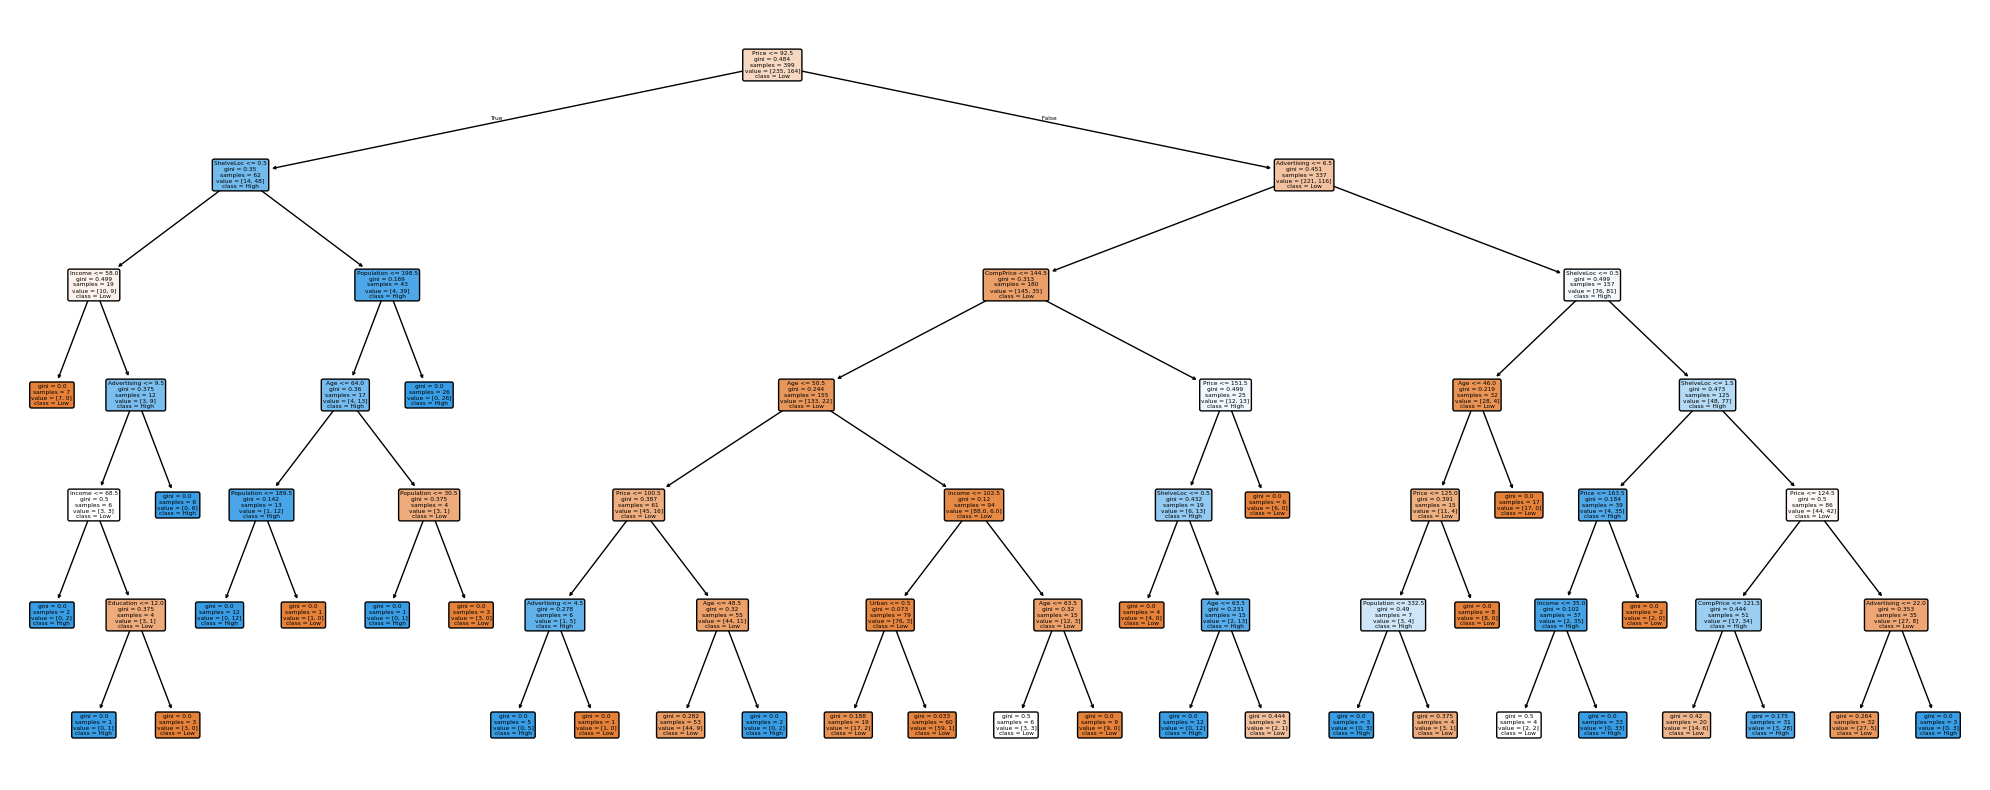

In [10]:
fig, ax = plt.subplots(figsize=(20, 8))
tree.plot_tree(clf, feature_names=X.columns,
               class_names=['Low', 'High'],
               filled=True, rounded=True, ax=ax)
plt.tight_layout()
plt.show()

The classification report below is evaluated on the **training data** — the same data the tree was trained on. You will likely see very high accuracy here. The cells after it evaluate on a held-out test set to get a more honest picture of how well the model generalizes to new examples.

In [11]:
print(classification_report(y, clf.predict(X)))

              precision    recall  f1-score   support

           0       0.89      0.99      0.93       235
           1       0.98      0.82      0.89       164

    accuracy                           0.92       399
   macro avg       0.93      0.90      0.91       399
weighted avg       0.92      0.92      0.92       399



In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
clf.fit(X_train, y_train)
print('\n')
pred = clf.predict(X_test)
print(classification_report(y_test, pred))

DecisionTreeClassifier(max_depth=6)



              precision    recall  f1-score   support

           0       0.80      0.73      0.76       121
           1       0.63      0.72      0.67        79

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.73      0.72      0.73       200



In [13]:
cm = pd.DataFrame(confusion_matrix(y_test, pred).T, index=['Low Sales', 'High Sales'], columns=['Low Sales', 'High Sales'])
cm.index.name = 'Predicted'
cm.columns.name = 'True'
cm

True,Low Sales,High Sales
Predicted,,
Low Sales,88,22
High Sales,33,57


## Regression Trees

Decision trees work for regression too — when the outcome is a continuous number rather than a category. Instead of predicting the most common class in a leaf, a regression tree predicts the **average value** of all training examples in that leaf.

The splitting logic is the same idea: at each step, try every possible split on every feature and choose the one that reduces prediction error the most. Here we use the Boston housing dataset to predict median home values (`medv`) from neighborhood characteristics.

We evaluate with **mean squared error (MSE)** — the average of squared differences between predicted and actual values. Lower is better.

In [14]:
url2 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Boston.csv'
boston_df = pd.read_csv(url2).drop('Unnamed: 0', axis='columns')
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [15]:
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [16]:
X = boston_df.drop('medv', axis=1)
y = boston_df.medv

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

In [18]:
regr = tree.DecisionTreeRegressor(max_depth=4)
regr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4)

[Text(0.45689655172413796, 0.9, 'lstat <= 7.81\nsquared_error = 92.491\nsamples = 253\nvalue = 23.049'),
 Text(0.1896551724137931, 0.7, 'rm <= 7.435\nsquared_error = 84.345\nsamples = 86\nvalue = 32.492'),
 Text(0.3232758620689655, 0.8, 'True  '),
 Text(0.06896551724137931, 0.5, 'dis <= 1.485\nsquared_error = 41.903\nsamples = 68\nvalue = 28.978'),
 Text(0.034482758620689655, 0.3, 'squared_error = 0.0\nsamples = 3\nvalue = 50.0'),
 Text(0.10344827586206896, 0.3, 'rm <= 6.556\nsquared_error = 22.499\nsamples = 65\nvalue = 28.008'),
 Text(0.06896551724137931, 0.1, 'squared_error = 2.618\nsamples = 25\nvalue = 23.748'),
 Text(0.13793103448275862, 0.1, 'squared_error = 16.496\nsamples = 40\nvalue = 30.67'),
 Text(0.3103448275862069, 0.5, 'ptratio <= 15.4\nsquared_error = 21.812\nsamples = 18\nvalue = 45.767'),
 Text(0.2413793103448276, 0.3, 'black <= 394.805\nsquared_error = 5.79\nsamples = 11\nvalue = 48.636'),
 Text(0.20689655172413793, 0.1, 'squared_error = 1.952\nsamples = 10\nvalue = 

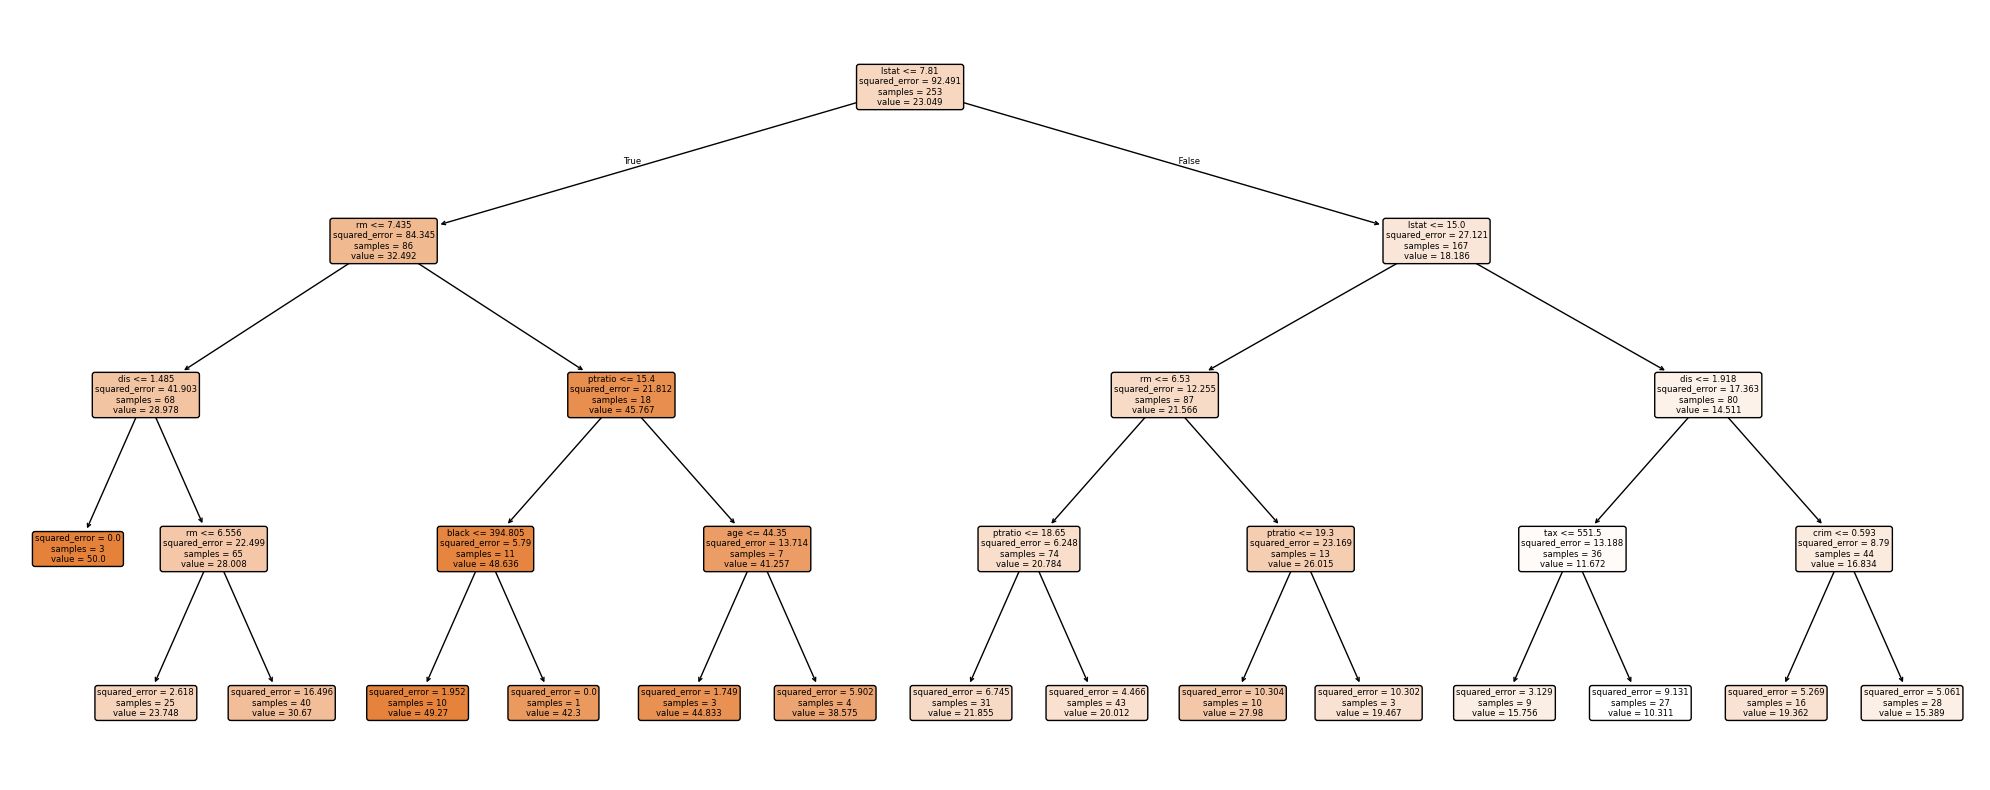

In [19]:
fig, ax = plt.subplots(figsize=(20, 8))
tree.plot_tree(regr, feature_names=X.columns,
               filled=True, rounded=True, ax=ax)
plt.tight_layout()
plt.show()

In [20]:
pred = regr.predict(X_test)
mean_squared_error(y_test, pred)

23.81737151382862

## Bagging and Random Forests

A single decision tree has a major weakness: **high variance**. If you train two trees on slightly different samples of the same data, you can end up with very different trees and very different predictions. This makes individual trees unreliable.

**Bagging** (Bootstrap Aggregation) addresses this by training hundreds of trees, each on a randomly resampled version of the training data, and then averaging their predictions. No single tree's quirks dominate the final answer.

**Random Forests** go one step further. With bagging, if one feature is a very strong predictor, most trees will use it as their first split — meaning all the trees end up looking similar, and averaging them doesn't help much. Random forests fix this by restricting each split to consider only a **random subset of features**. This forces different trees to explore different parts of the data, making them more independent and more useful to average together.

The key parameter is `max_features`: how many features to consider at each split. A common default is the square root of the total number of features. Using all features (`max_features=13` here) is equivalent to plain bagging — this serves as our baseline for comparison.

In [21]:
X.shape

(506, 13)

In [22]:
# Bagging: using all features
regr = RandomForestRegressor(max_features=13, random_state=1)
regr.fit(X_train, y_train)

RandomForestRegressor(max_features=13, random_state=1)

In [23]:
pred = regr.predict(X_test)
mean_squared_error(y_test, pred)

16.300959351778662

In [24]:
# Random forest with m = 6
regr = RandomForestRegressor(max_features=6, random_state=1)
regr.fit(X_train, y_train)

RandomForestRegressor(max_features=6, random_state=1)

In [25]:
pred = regr.predict(X_test)
mean_squared_error(y_test, pred)

15.294080379446633

### Feature Importance

One advantage of random forests is that they give us a measure of **feature importance**: which features did the trees find most useful for making predictions?

Importance is measured by how much each feature reduces prediction error across all the splits it was used for, averaged across all the trees. A feature that appears in many splits and consistently produces big reductions in error gets a high importance score.

This is useful for understanding your data — which inputs actually drive the outcome? It can also guide feature selection: if a feature has near-zero importance, it may not be worth including. The bar chart below shows importance as percentages. Features toward the top contributed most to the model's predictions.

<Axes: >

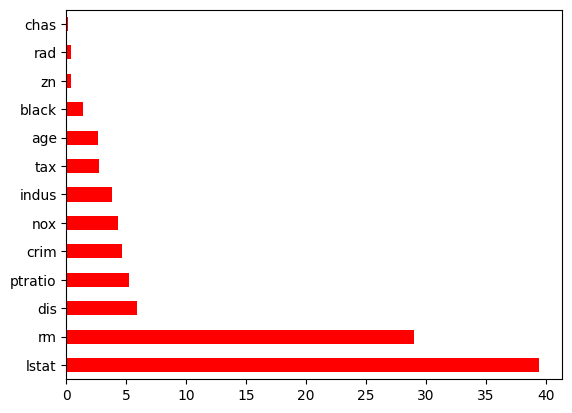

In [26]:
importance = pd.Series(regr.feature_importances_ * 100, index = X.columns)
importance = importance.sort_values(axis=0, ascending = False)
importance.plot(kind='barh', color='r', )

### Interactive Random Forest Explorer

Use the sliders below to explore how the number of trees and features considered per split affect prediction error. Notice that more trees generally helps but with diminishing returns, and that restricting the number of features per split often improves generalization by decorrelating the trees.

In [27]:
import ipywidgets as widgets

def fit_rf_interactive(n_estimators, max_features):
    rf = RandomForestRegressor(n_estimators=n_estimators, max_features=max_features, random_state=1)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    mse = mean_squared_error(y_test, pred_rf)
    print(f"Trees: {n_estimators}, Features per split: {max_features}")
    print(f"Test MSE: {mse:.3f}")

widgets.interact(
    fit_rf_interactive,
    n_estimators=widgets.IntSlider(value=100, min=10, max=500, step=10, description="Num Trees:"),
    max_features=widgets.IntSlider(value=6, min=1, max=13, step=1, description="Max Features:")
);

interactive(children=(IntSlider(value=100, description='Num Trees:', max=500, min=10, step=10), IntSlider(valu…

## Boosting

Boosting is another way to combine many trees, but it works very differently from random forests.

In random forests, all the trees are trained **independently** and in parallel. In boosting, the trees are trained **sequentially** — each new tree focuses on correcting the mistakes of the previous ones.

Here's the intuition: start with a simple prediction (like the mean), calculate where it went wrong (the residuals — the gaps between predictions and reality), then train a small tree to predict those residuals. Add that tree's predictions to your running total, recalculate the residuals, and repeat. Each iteration nudges the model a little closer to the right answer in the places where it was most wrong.

The key parameters for boosting:
- `n_estimators`: how many trees to build. Unlike random forests, boosting **can** overfit if you build too many trees — each new tree is tuned to the residuals of the previous ones, so eventually the model starts chasing noise
- `learning_rate`: how much each new tree contributes. Smaller values require more trees but often give better final results
- Tree depth: boosting typically works best with shallow trees — even just a single split

In [28]:
regr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, random_state=1)
regr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=500, random_state=1)

In [29]:
pred = regr.predict(X_test)

<Axes: >

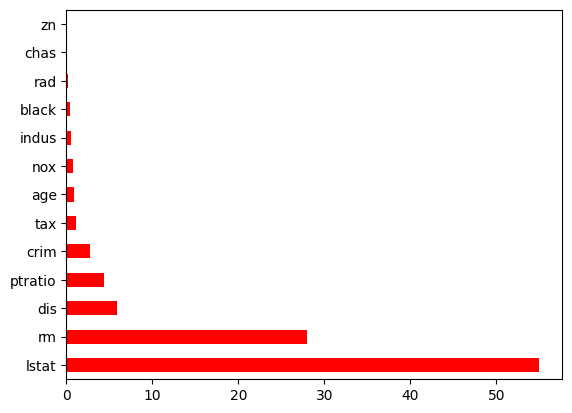

In [30]:
importance = pd.Series(regr.feature_importances_ * 100, index = X.columns)
importance = importance.sort_values(axis=0, ascending = False)
importance.plot(kind='barh', color='r', )

In [31]:
mean_squared_error(y_test, pred)

15.59389107490677

## Trees vs. Linear Models

Decision trees and linear models partition the predictor space in fundamentally different ways.

**Linear models** (logistic regression, linear regression) impose a global linear boundary — they assume one straight line (or hyperplane) separates the classes or describes the response across the entire predictor space. That's a powerful assumption when it's true, but it fails badly when the true boundary is curved or piecewise.

**Decision trees** recursively split the predictor space into rectangular boxes. Each box makes its own constant prediction. The result is a step-function approximation that can capture complex, non-linear patterns — but only through axis-aligned cuts.

When to prefer each:
- **Linear model** — when the true boundary is roughly linear, or when the dataset is small and a simple model reduces variance.
- **Decision tree** — when the boundary is highly non-linear or jagged, or when interpretability of individual decision rules matters (e.g. medical diagnosis, credit scoring).

In practice, a single decision tree rarely wins on raw predictive accuracy. Its real value is interpretability and the building block it provides for ensemble methods like random forests and boosting.

## Strengths and Weaknesses of Decision Trees

**Strengths:**
- Easy to explain — even easier to communicate than linear regression
- More closely mirror how humans actually make decisions
- Can be displayed graphically and inspected node by node
- Handle categorical predictors natively — no dummy variables needed

**Weaknesses:**
- Predictive accuracy is often lower than other methods (single trees have high variance)
- Non-robust: a small change in the training data can produce a very different tree

The high-variance problem is exactly why bagging and random forests exist — they build many trees and average them, recovering stability without sacrificing the tree's ability to model non-linear boundaries.